In [1]:
from datasets.fsmol_dock import FsDockDataset
from datasets.partitioned_fsmol_dock import FsDockDatasetPartitioned
import torch
from Bio.PDB import PDBParser, DSSP, PPBuilder
from Bio.SeqUtils.ProtParam import ProteinAnalysis
import numpy as np
import os
import pandas as pd
from collections import defaultdict
import freesasa

/home/alon.kitin/miniconda3/envs/FSdock/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/alon.kitin/miniconda3/envs/FSdock/lib/python3.9/site-packages/Bio/pairwise2.py:278: BiopythonDeprecationWarning: Bio.pairwise2 has been deprecated, and we intend to remove it in a future release of Biopython. As an alternative, please consider using Bio.Align.PairwiseAligner as a replacement, and contact the Biopython developers if you still need the Bio.pairwise2 module.
  warnings.warn(


In [2]:
assays = ['CHEMBL1119333',
 'CHEMBL1614027',
 'CHEMBL1614423',
 'CHEMBL1963715',
 'CHEMBL1963723',
 'CHEMBL1963731',
 'CHEMBL1963741',
 'CHEMBL1963756',
 'CHEMBL1963810',
 'CHEMBL1963818',
 'CHEMBL1963819',
 'CHEMBL1963824',
 'CHEMBL1963825',
 'CHEMBL1963827',
 'CHEMBL1963831',
 'CHEMBL1964101',
 'CHEMBL1964115',
 'CHEMBL3214944',
 'CHEMBL3431930',
 'CHEMBL3431932']

tasks = pd.read_csv('/home/alon.kitin/fs-dock/data/fsdock/test_tasks.csv')
tasks = tasks[tasks['assay_id'].isin(assays)]

In [16]:
s = '''
CHEMBL1119333	0.090330097
CHEMBL1614027	0.0255625
CHEMBL1614423	0.043609756
CHEMBL1963715	0.006090909
CHEMBL1963723	0.053982833
CHEMBL1963731	0.028979592
CHEMBL1963741	-0.001089109
CHEMBL1963756	-0.006285068
CHEMBL1963810	0.013086957
CHEMBL1963818	0.066119403
CHEMBL1963819	0.013260042
CHEMBL1963824	0.010262009
CHEMBL1963825	0.044590909
CHEMBL1963827	0.01312987
CHEMBL1963831	0.10970339
CHEMBL1964101	0.021673469
CHEMBL1964115	0.063911917
CHEMBL3214944	-0.006827586
CHEMBL3431930	0.026694915
CHEMBL3431932	0.017157205
'''.strip().split('\n')
success = dict()
for l in s:
    l = l.split('\t')
    success[l[0]] = float(l[1])

In [17]:
pdb_files = tasks[['assay_id','protein_path']].drop_duplicates()

In [18]:
def extract_features_from_pdb(pdb_file):
    parser = PDBParser(QUIET=True)
    structure = parser.get_structure("protein", pdb_file)
    model = structure[0]

    # Extract sequence
    ppb = PPBuilder()
    sequence = "".join([str(pp.get_sequence()) for pp in ppb.build_peptides(model)])
    analysis = ProteinAnalysis(sequence)

    # General sequence features
    features = {}
    features["length"] = len(sequence)
    features["molecular_weight"] = analysis.molecular_weight()
    features["aromaticity"] = analysis.aromaticity()
    features["instability_index"] = analysis.instability_index()
    features["isoelectric_point"] = analysis.isoelectric_point()
    features["gravy"] = analysis.gravy()

    # Amino acid composition
    aa_composition = analysis.get_amino_acids_percent()
    for aa, perc in aa_composition.items():
        features[f"aa_{aa}"] = perc
    freesasa_struct = freesasa.Structure(pdb_file)
    features['sasa'] = freesasa.calc(freesasa_struct).totalArea()
    
    # DSSP for secondary structure content
    # try:
    #     dssp = DSSP(model, pdb_file)
    #     ss_counts = {"H": 0, "B": 0, "E": 0, "G": 0, "I": 0, "T": 0, "S": 0, "-": 0}
    #     for _, dssp_data in dssp.property_list:
    #         ss = dssp_data[2]
    #         ss_counts[ss] = ss_counts.get(ss, 0) + 1

    #     total_residues = sum(ss_counts.values())
    #     features["helix_content"] = (ss_counts["H"] + ss_counts["G"] + ss_counts["I"]) / total_residues
    #     features["sheet_content"] = (ss_counts["E"] + ss_counts["B"]) / total_residues
    #     features["coil_content"] = (ss_counts["T"] + ss_counts["S"] + ss_counts["-"]) / total_residues
    # except Exception as e:
    #     print("DSSP failed:", e)

    # # Ligand-binding site: count of residues within 5 Å of ligand atoms
    # ligand_atoms = [atom for atom in model.get_atoms() if atom.get_parent().id[0].startswith("H_")]
    # binding_residues = set()
    # for chain in model:
    #     for residue in chain:
    #         if residue.id[0] == " ":
    #             for atom in residue:
    #                 for ligand_atom in ligand_atoms:
    #                     distance = atom - ligand_atom
    #                     if distance < 5.0:
    #                         binding_residues.add(residue)
    #                         break
    # features["binding_site_residue_count"] = len(binding_residues)

    return features

In [19]:
features = {}
for task in pdb_files.iterrows():
    task= task[1]
    features[task['assay_id']] = extract_features_from_pdb(task['protein_path'])
    features[task['assay_id']]['label'] = success[task['assay_id']]
features_df = pd.DataFrame.from_dict(features, orient='index')

In [20]:

X = features_df[['length', 'molecular_weight', 'aromaticity', 'instability_index',
       'isoelectric_point', 'gravy']]

y = features_df['label']

In [21]:
np.array(features_df['label'])

array([ 0.0903301 ,  0.0255625 ,  0.04360976,  0.00609091,  0.05398283,
        0.02897959, -0.00108911, -0.00628507,  0.01308696,  0.0661194 ,
        0.01326004,  0.01026201,  0.04459091,  0.01312987,  0.10970339,
        0.02167347,  0.06391192, -0.00682759,  0.02669491,  0.0171572 ])

In [22]:
features_df.corr()['label'].abs().sort_values(ascending=False)

label                1.000000
aa_L                 0.599735
aa_K                 0.541007
aa_S                 0.520997
aa_W                 0.454478
aa_I                 0.450547
aa_A                 0.446899
gravy                0.438934
aa_V                 0.424478
aa_P                 0.419997
sasa                 0.400802
aa_T                 0.384861
molecular_weight     0.369186
length               0.356882
aa_G                 0.308078
isoelectric_point    0.304099
aa_M                 0.257143
aa_N                 0.252965
instability_index    0.231400
aromaticity          0.167630
aa_H                 0.131977
aa_D                 0.128867
aa_Q                 0.123766
aa_E                 0.123018
aa_R                 0.082518
aa_C                 0.056256
aa_F                 0.033797
aa_Y                 0.003552
Name: label, dtype: float64

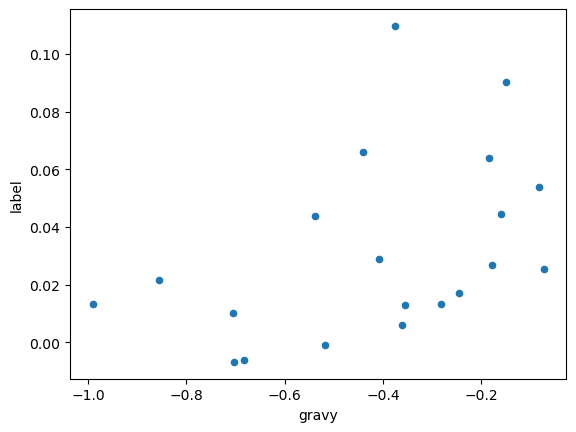

In [23]:
def plot(name):
    features_df[[name,'label']].plot.scatter(x=name,y='label')

plot('gravy')

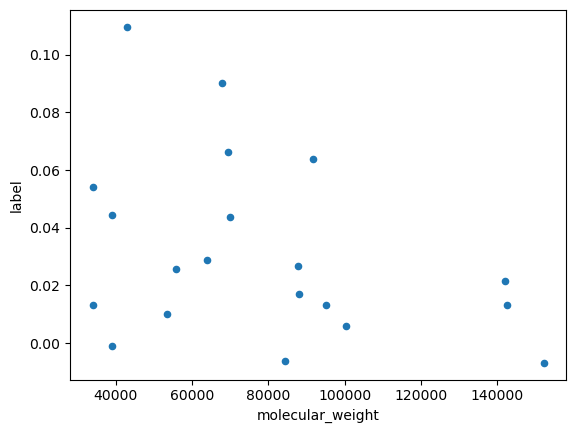

In [24]:
plot('molecular_weight')

In [25]:
q1 = {'length': 313.0,
 'molecular_weight': 35395.22720000003,
 'aromaticity': 0.06426155580608794,
 'instability_index': 32.42056603773585,
 'isoelectric_point': 5.337374687194824,
 'gravy': -0.5788461538461545,
 'sasa': 16901.56895918314}
q09 = {'length': 1203.0,
 'molecular_weight': 131883.9971000008,
 'aromaticity': 0.12093023255813953,
 'instability_index': 54.60740773539615,
 'isoelectric_point': 9.239496040344235,
 'gravy': 0.41997167138810254,
 'sasa': 87678.44443773787}

In [26]:
mask = None
for feature in ['length', 'molecular_weight', 'aromaticity',
       'isoelectric_point', 'gravy']:
    if mask is None:
        mask = (features_df[feature] > q1[feature]) & (features_df[feature] < q09[feature])
    else:
        mask = mask & (features_df[feature] > q1[feature]) & (features_df[feature] < q09[feature])
features_df[mask]['label'].mean(),features_df[mask]['label'].size 

(0.044653129166666666, 12)